# **Tubuculosis MLP Classification (Siriraj Data Only)**

## **Import Libraries**

In [1]:
import os
import pandas as pd
import numpy as np
import gc
from pathlib import Path
from typing import List, Dict
import re
import copy

# ==== Torch ====
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

# ==== Scikit Learn ====
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    f1_score, 
    accuracy_score
)

# ==== Visulization ====
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns

# ==== Chroma Vector Database ====
import chromadb
from chromadb.config import Settings

## **Project Setup**

In [2]:
# ==== Check Device ==== 
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(torch.version.cuda)
    print(f"✅ Using CUDA device: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ CUDA not available. Using CPU.")
print(f"Device: {DEVICE}")

12.8
✅ Using CUDA device: NVIDIA GeForce RTX 3090 Ti
Device: cuda


## **Configuration Parameters**

In [3]:
# ==== Paths ====
DB_PATH: str = "../../data/chroma_db"

# ==== Vector Database ====
DB_NAME: str = "siriraj_vector_db"

# ==== Data Splitting ====
n_folds: int = 5
val_size: float = 0.25

# ==== Seed Setting ====
seed: int = 42

# ==== MLP Classification Architecture ====
INPUT_SIZE: int = 512
HIDDEN_SIZE: int = 256 
OUTPUT_SIZE: int = 1
HIDDEN_DIMS: List[int] = [256, 128, 64]
DROPOUT: float = 0.5

# ==== Early Stopping ====
PATIENCE: int = 10
MODE: str = "min"
MONITOR: str = "val_loss"
DELTA: float = 0.001

# ==== Training Loop ====
EPOCHS: int = 30
BATCH_SIZE: int = 8
LEARNING_RATE: float = 3e-4
SHUFFLE: bool = True

# ==== Optimizer ====
OPTIMIZER: str = "adam"

# ==== Loss Function ====
LOSS_FUNCTION: str = "focal_loss"

print("✅ Configuration loaded.")

✅ Configuration loaded.


## **Fetch Data in Vector Database**

In [4]:
# ==== Initialize ChromaDB Client ====
print(f"📂 Connecting to ChromaDB at: {DB_PATH}")
chroma_client = chromadb.PersistentClient(path=DB_PATH)

# ==== Create or Get Collection ====
collection = chroma_client.get_collection(name=DB_NAME)
print(f"✅ Collection '{DB_NAME}' ready.")
print(f"📊 Current Item Count: {collection.count()}")

# ==== Fetch all data ====
results = collection.get(include=['embeddings', 'metadatas'])
embeddings = np.array(results['embeddings'])
metadatas = results['metadatas']

# ==== Extract labels (Metadata is a list of dicts) ====
labels = [m['label'] for m in metadatas]
labels = np.array(labels)

print(f"✅ Loaded {len(embeddings)} samples.")
print(f"   - Non-TB:   {sum(labels == 0)}")
print(f"   - TB Cases: {sum(labels == 1)}")

📂 Connecting to ChromaDB at: ../../data/chroma_db
✅ Collection 'siriraj_vector_db' ready.
📊 Current Item Count: 512
✅ Loaded 512 samples.
   - Non-TB:   325
   - TB Cases: 187


## **Data Preparation**

### Build Dataframe from Database

In [5]:
def build_df_from_db(collection) -> pd.DataFrame :
    # ==== Fetch Data from ChromaDB ====
    results = collection.get(include = ["embeddings", "metadatas"])

    embeddings = np.array(results["embeddings"])
    metadatas = results["metadatas"]
    ids = results['ids']

    # ==== Build embedding collumns ====
    emb_dim = embeddings.shape[1]
    emb_columns = [f"emb_{i}" for i in range(emb_dim)]
    emb_df      = pd.DataFrame(embeddings, columns=emb_columns)

    # ==== Build metadata columns ====
    meta_df = pd.DataFrame(metadatas)             # file_name, label, category
    meta_df['id'] = ids

    # ==== Combine metadata + embeddings ====
    df = pd.concat(
        [meta_df[['id', 'file_name', 'category', 'label']], emb_df],
        axis=1
    )

    return df

### Run Build DataFrame 

In [6]:
df = build_df_from_db(collection)

print(f"📊 DataFrame shape   : {df.shape}")
print(f"🔹 Non-TB samples    : {len(df[df['label'] == 0])}")
print(f"🔹 TB samples        : {len(df[df['label'] == 1])}")
print(f"\n📋 Column overview:")
print(df.iloc[:, :6].head())

📊 DataFrame shape   : (512, 516)
🔹 Non-TB samples    : 325
🔹 TB samples        : 187

📋 Column overview:
        id      file_name category  label     emb_0     emb_1
0  audio_0  002_03-19.wav   Non-TB      0 -1.137581  0.988355
1  audio_1  002_03-26.wav   Non-TB      0 -1.274177  1.258287
2  audio_2  004_07-03.wav   Non-TB      0 -1.325635 -0.402892
3  audio_3  002_03-20.wav   Non-TB      0 -1.511500  3.202736
4  audio_4  014_05-01.wav   Non-TB      0 -2.206126  1.109271


### Build Subject Table

In [7]:
def extract_subject_id(filename):
    """Extracts the subject ID (first 3 digits) from the filename."""
    match = re.match(r"^(\d{3})_", filename)
    if match:
        return match.group(1)
    else:
        # Fallback if pattern doesn't match perfectly
        return filename.split('_')[0]


results = collection.get(include=['embeddings', 'metadatas'])
metadatas = results['metadatas'] 

df = pd.DataFrame(metadatas) 

# Add 'subject_id' column
df['subject_id'] = df['file_name'].apply(extract_subject_id)

print(f"Total samples: {len(df)}")
print(f"Unique subjects: {df['subject_id'].nunique()}")

Total samples: 512
Unique subjects: 15


In [8]:
def build_subject_table(df):
    """Creates a DataFrame with one row per subject and their majority label."""
    # Group by subject_id
    # Get the most frequent label (mode)
    subject_df = (
        df.groupby("subject_id")["label"]
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={"label": "subject_label"})
    )
    return subject_df

subject_table = build_subject_table(df)

# X_subj: List of subject IDs
# y_subj: List of labels for stratification
X_subj = subject_table["subject_id"].values
y_subj = subject_table["subject_label"].values

print(subject_table)
print("="*80)
print(f"\nTotal Unique Subjects: {len(X_subj)}")

   subject_id  subject_label
0         001              0
1         002              0
2         003              0
3         004              0
4         005              0
5         006              1
6         007              0
7         008              1
8         009              1
9         011              1
10        012              1
11        013              0
12        014              0
13        015              1
14        016              1

Total Unique Subjects: 15


### Helper Function

In [9]:
def filter_by_subjects(df: pd.DataFrame, subject_ids) -> pd.DataFrame:
    return df[df["subject_id"].isin(set(subject_ids))].reset_index(drop=True)


def print_detailed_stats(df: pd.DataFrame, subj_ids, split_name: str, total_n: int):
    subset         = df[df["subject_id"].isin(subj_ids)]
    tb_df          = subset[subset["label"] == 1]
    nontb_df       = subset[subset["label"] == 0]
    tb_subjs       = sorted(tb_df["subject_id"].unique().tolist())
    nontb_subjs    = sorted(nontb_df["subject_id"].unique().tolist())
    ratio          = len(subj_ids) / total_n

    print(f"  {split_name.upper():5s} SET : {len(subj_ids):>2} subjects ({ratio:.2%})")
    print(f"   ├─ TB    (1) : {len(tb_df):>4} segments | IDs: {', '.join(tb_subjs)}")
    print(f"   └─ NonTB (0) : {len(nontb_df):>4} segments | IDs: {', '.join(nontb_subjs)}")

## **Stratified K Fold for Splitting Data**

In [10]:
def build_cv_folds(
    df: pd.DataFrame,
    n_folds: int,
    val_size: float,   # of train+val → val  (0.25 × 0.80 = 0.20 overall)
    random_seed: int,
) -> dict:

    print(f"\n{'='*60}")
    print(f"  Subject-Level Stratified {n_folds}-Fold CV")
    print(f"  Samples   : {len(df)}  |  Subjects: {df['subject_id'].nunique()}")
    print(f"  TB        : {sum(df['label']==1)}  |  Non-TB  : {sum(df['label']==0)}")
    print(f"{'='*60}")

    st     = build_subject_table(df)
    X_subj = st["subject_id"].values
    y_subj = st["subject_label"].values
    n_total = len(X_subj)

    outer_skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_seed)
    all_folds = []

    for fold, (train_val_idx, test_idx) in enumerate(outer_skf.split(X_subj, y_subj), start=1):

        # ==== Outer: train+val vs test ====
        train_val_subj = X_subj[train_val_idx]
        y_train_val    = y_subj[train_val_idx]
        test_subj      = X_subj[test_idx]

        # ==== Inner: train vs val ====
        inner = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=random_seed + fold)
        inner_train_idx, inner_val_idx = next(inner.split(train_val_subj, y_train_val))

        train_subj = train_val_subj[inner_train_idx]
        val_subj   = train_val_subj[inner_val_idx]

        # ==== Leakage checks ====
        assert set(train_subj).isdisjoint(val_subj),  f"Fold {fold}: train/val overlap!"
        assert set(train_subj).isdisjoint(test_subj), f"Fold {fold}: train/test overlap!"
        assert set(val_subj).isdisjoint(test_subj),   f"Fold {fold}: val/test overlap!"

        df_train = filter_by_subjects(df, train_subj)
        df_val   = filter_by_subjects(df, val_subj)
        df_test  = filter_by_subjects(df, test_subj)

        print(f"\n--- Fold {fold} ---")
        print_detailed_stats(df, set(train_subj), "Train", n_total)
        print_detailed_stats(df, set(val_subj),   "Val",   n_total)
        print_detailed_stats(df, set(test_subj),  "Test",  n_total)

        all_folds.append({
            "fold"       : fold,
            "seed"       : random_seed + fold,
            "train_subj" : sorted(train_subj.tolist()),
            "val_subj"   : sorted(val_subj.tolist()),
            "test_subj"  : sorted(test_subj.tolist()),
            "df_train"   : df_train,
            "df_val"     : df_val,
            "df_test"    : df_test,
        })

    print(f"\n{'='*60}")
    print(f"  ✅ {n_folds} folds built — No subject leakage confirmed")
    print(f"{'='*60}\n")

    return {"subject_table": st, "folds": all_folds}

In [11]:
splits_info = build_cv_folds(df, n_folds=n_folds, val_size=val_size, random_seed=seed)


  Subject-Level Stratified 5-Fold CV
  Samples   : 512  |  Subjects: 15
  TB        : 187  |  Non-TB  : 325

--- Fold 1 ---
  TRAIN SET :  9 subjects (60.00%)
   ├─ TB    (1) :  125 segments | IDs: 006, 009, 011, 015, 016
   └─ NonTB (0) :  133 segments | IDs: 005, 007, 013, 014
  VAL   SET :  3 subjects (20.00%)
   ├─ TB    (1) :   20 segments | IDs: 012
   └─ NonTB (0) :  150 segments | IDs: 002, 004
  TEST  SET :  3 subjects (20.00%)
   ├─ TB    (1) :   42 segments | IDs: 008
   └─ NonTB (0) :   42 segments | IDs: 001, 003

--- Fold 2 ---
  TRAIN SET :  9 subjects (60.00%)
   ├─ TB    (1) :  149 segments | IDs: 006, 008, 009, 012, 016
   └─ NonTB (0) :  103 segments | IDs: 001, 003, 007, 014
  VAL   SET :  3 subjects (20.00%)
   ├─ TB    (1) :    1 segments | IDs: 011
   └─ NonTB (0) :  150 segments | IDs: 002, 004
  TEST  SET :  3 subjects (20.00%)
   ├─ TB    (1) :   37 segments | IDs: 015
   └─ NonTB (0) :   72 segments | IDs: 005, 013

--- Fold 3 ---
  TRAIN SET :  9 subjects (

## **MLP Classification**

In [12]:
class MLPModel(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float):
        super().__init__()

        self.input_dim    = input_dim
        self.hidden_dims  = hidden_dims
        self.dropout      = dropout

        layers   = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim
        
        # Output layer — single logit for binary classification
        layers.append(nn.Linear(prev_dim, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def get_model_info(self) -> Dict:
        """Return architecture summary."""
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {
            "input_dim"       : self.input_dim,
            "hidden_dims"     : self.hidden_dims,
            "dropout"         : self.dropout,
            "total_params"    : total,
            "trainable_params": trainable,
        }

### Get Fold Embeddings Function (Helper function)

In [13]:
def get_embeddings_for_subjects(subject_ids, df, embeddings):
    mask = df["subject_id"].isin(subject_ids)
    X = embeddings[mask.values]
    y = df.loc[mask, "label"].values.astype(int)
    return X, y


def get_fold_data(fold_idx, splits_info, df, embeddings):
    sp = splits_info["folds"][fold_idx]
    X_tr, y_tr = get_embeddings_for_subjects(sp["train_subj"], df, embeddings)
    X_va, y_va = get_embeddings_for_subjects(sp["val_subj"],   df, embeddings)
    X_te, y_te = get_embeddings_for_subjects(sp["test_subj"],  df, embeddings)
    return X_tr, y_tr, X_va, y_va, X_te, y_te

print("✅ Fold embedding helpers defined.")

✅ Fold embedding helpers defined.


In [14]:
fold_data = []
for fold_idx in range(n_folds):
    data_tuple = get_fold_data(fold_idx, splits_info, df, embeddings)
    fold_data.append(data_tuple)
print(f"✅ Data tuples for all {n_folds} folds prepared.")

✅ Data tuples for all 5 folds prepared.


### Build MLP Model

In [15]:
model = MLPModel(input_dim=INPUT_SIZE, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT)
info = model.get_model_info()
print(f"\nModel Architecture Summary:")
print(model.model)
print(f"\nInput dim       : {info['input_dim']}")
print(f"Hidden dims     : {info['hidden_dims']}")
print(f"Dropout         : {info['dropout']}")
print(f"Total params    : {info['total_params']:,}")
print(f"Trainable params: {info['trainable_params']:,}")


Model Architecture Summary:
Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=128, out_features=64, bias=True)
  (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.5, inplace=False)
  (12): Linear(in_features=64, out_features=1, bias=True)
)

Input dim       : 512
Hidden dims     : [256, 128, 64]
Dropout         : 0.5
Total params    : 173,441
Trainable params: 173,441


## **Training MLP Classification Model**

### Early Stopping

In [16]:
class EarlyStopping:
    def __init__(self, patience: int, mode: str , monitor: str, delta: float, verbose: bool = True):
        self.patience      = patience
        self.delta         = delta
        self.verbose       = verbose
        self.mode          = mode
        self.monitor       = monitor
        self.best_val_loss = float("inf")
        self.best_state    = None
        self.bad_epochs    = 0
        self.best_epoch    = 0
        self.early_stop    = False

    def __call__(self, val_loss: float, model: nn.Module, epoch: int) -> bool:
        improved = val_loss < (self.best_val_loss - self.delta)
        if improved:
            if self.verbose:
                print(f"  ✅ Val loss improved: {self.best_val_loss:.4f} → {val_loss:.4f}  (epoch {epoch+1})")
            self.best_val_loss = val_loss
            self.best_state    = copy.deepcopy(model.state_dict())
            self.bad_epochs    = 0
            self.best_epoch    = epoch
        else:
            self.bad_epochs += 1
            if self.verbose:
                print(f"  ❌ No improvement in val loss: {val_loss:.4f} (best: {self.best_val_loss:.4f})  [bad epochs: {self.bad_epochs}/{self.patience}]")
            if self.bad_epochs >= self.patience:
                if self.verbose:
                    print(f"  ⏰ Early stopping triggered after {self.bad_epochs} bad epochs.")
                self.early_stop = True
            return self.early_stop
    
    def restore_best_weights(self, model: nn.Module) -> None:
        """Load the best weights back into the model."""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
            if self.verbose:
                print(f"\n✅ Best weights restored from epoch {self.best_epoch+1} "
                      f"(val loss: {self.best_val_loss:.4f})")

### Training Loop

In [17]:
all_fold_results = []

print("\n" + "="*80)
print(f"Starting Training on {n_folds} Folds...")
print(f"Device: {DEVICE}")
print("="*80)

for fold_idx in range(n_folds):
    print(f"\n{'='*60}")
    print(f"  Fold {fold_idx+1} / {n_folds}")
    print(f"{'='*60}")

    X_train, y_train, X_val, y_val, X_test, y_test = fold_data[fold_idx]

    X_train_t = torch.FloatTensor(X_train).to(DEVICE)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
    X_val_t   = torch.FloatTensor(X_val).to(DEVICE)
    y_val_t   = torch.FloatTensor(y_val).unsqueeze(1).to(DEVICE)
    X_test_t  = torch.FloatTensor(X_test).to(DEVICE)
    y_test_t  = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

    train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    val_dataset   = torch.utils.data.TensorDataset(X_val_t, y_val_t)
    test_dataset  = torch.utils.data.TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

    # ==== Model & Optimizer ====
    model = MLPModel(input_dim=INPUT_SIZE, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    early_stopping = EarlyStopping(
        patience = PATIENCE,
        mode     = MODE,
        monitor  = MONITOR,
        delta    = DELTA,
        verbose  = True
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    # ==== Training Loop ====
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = F.binary_cross_entropy_with_logits(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss /= total
        train_acc = correct / total

        # ==== Validation ====
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = F.binary_cross_entropy_with_logits(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)

                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        val_loss /= total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if early_stopping(val_loss, model, epoch):
            early_stopping.restore_best_weights(model)
            print(f"  ⏰ Stopping early at epoch {epoch+1}")
            break
        print("-"*60)
    
    # Store fold results
    all_fold_results.append({
        "fold"       : fold_idx+1,
        "model"      : model,
        "history"    : history,
        "best_val_loss": early_stopping.best_val_loss,
        "best_epoch" : early_stopping.best_epoch + 1,
        "final_val_acc" : history["val_acc"][early_stopping.best_epoch] if history["val_acc"] else 0,
    })

print("\n✅ Training Complete.")


Starting Training on 5 Folds...
Device: cuda

  Fold 1 / 5
Epoch 1/30 | Train Loss: 0.6794, Train Acc: 0.5977 | Val Loss: 0.5861, Val Acc: 0.9588
  ✅ Val loss improved: inf → 0.5861  (epoch 1)
------------------------------------------------------------
Epoch 2/30 | Train Loss: 0.6119, Train Acc: 0.7070 | Val Loss: 0.5692, Val Acc: 0.9235
  ✅ Val loss improved: 0.5861 → 0.5692  (epoch 2)
------------------------------------------------------------
Epoch 3/30 | Train Loss: 0.5569, Train Acc: 0.7344 | Val Loss: 0.5323, Val Acc: 0.9000
  ✅ Val loss improved: 0.5692 → 0.5323  (epoch 3)
------------------------------------------------------------
Epoch 4/30 | Train Loss: 0.4915, Train Acc: 0.8164 | Val Loss: 0.5328, Val Acc: 0.8706
  ❌ No improvement in val loss: 0.5328 (best: 0.5323)  [bad epochs: 1/10]
------------------------------------------------------------
Epoch 5/30 | Train Loss: 0.4470, Train Acc: 0.8398 | Val Loss: 0.4691, Val Acc: 0.9118
  ✅ Val loss improved: 0.5323 → 0.4691  

### Visualization of Early Stopping Training per Fold

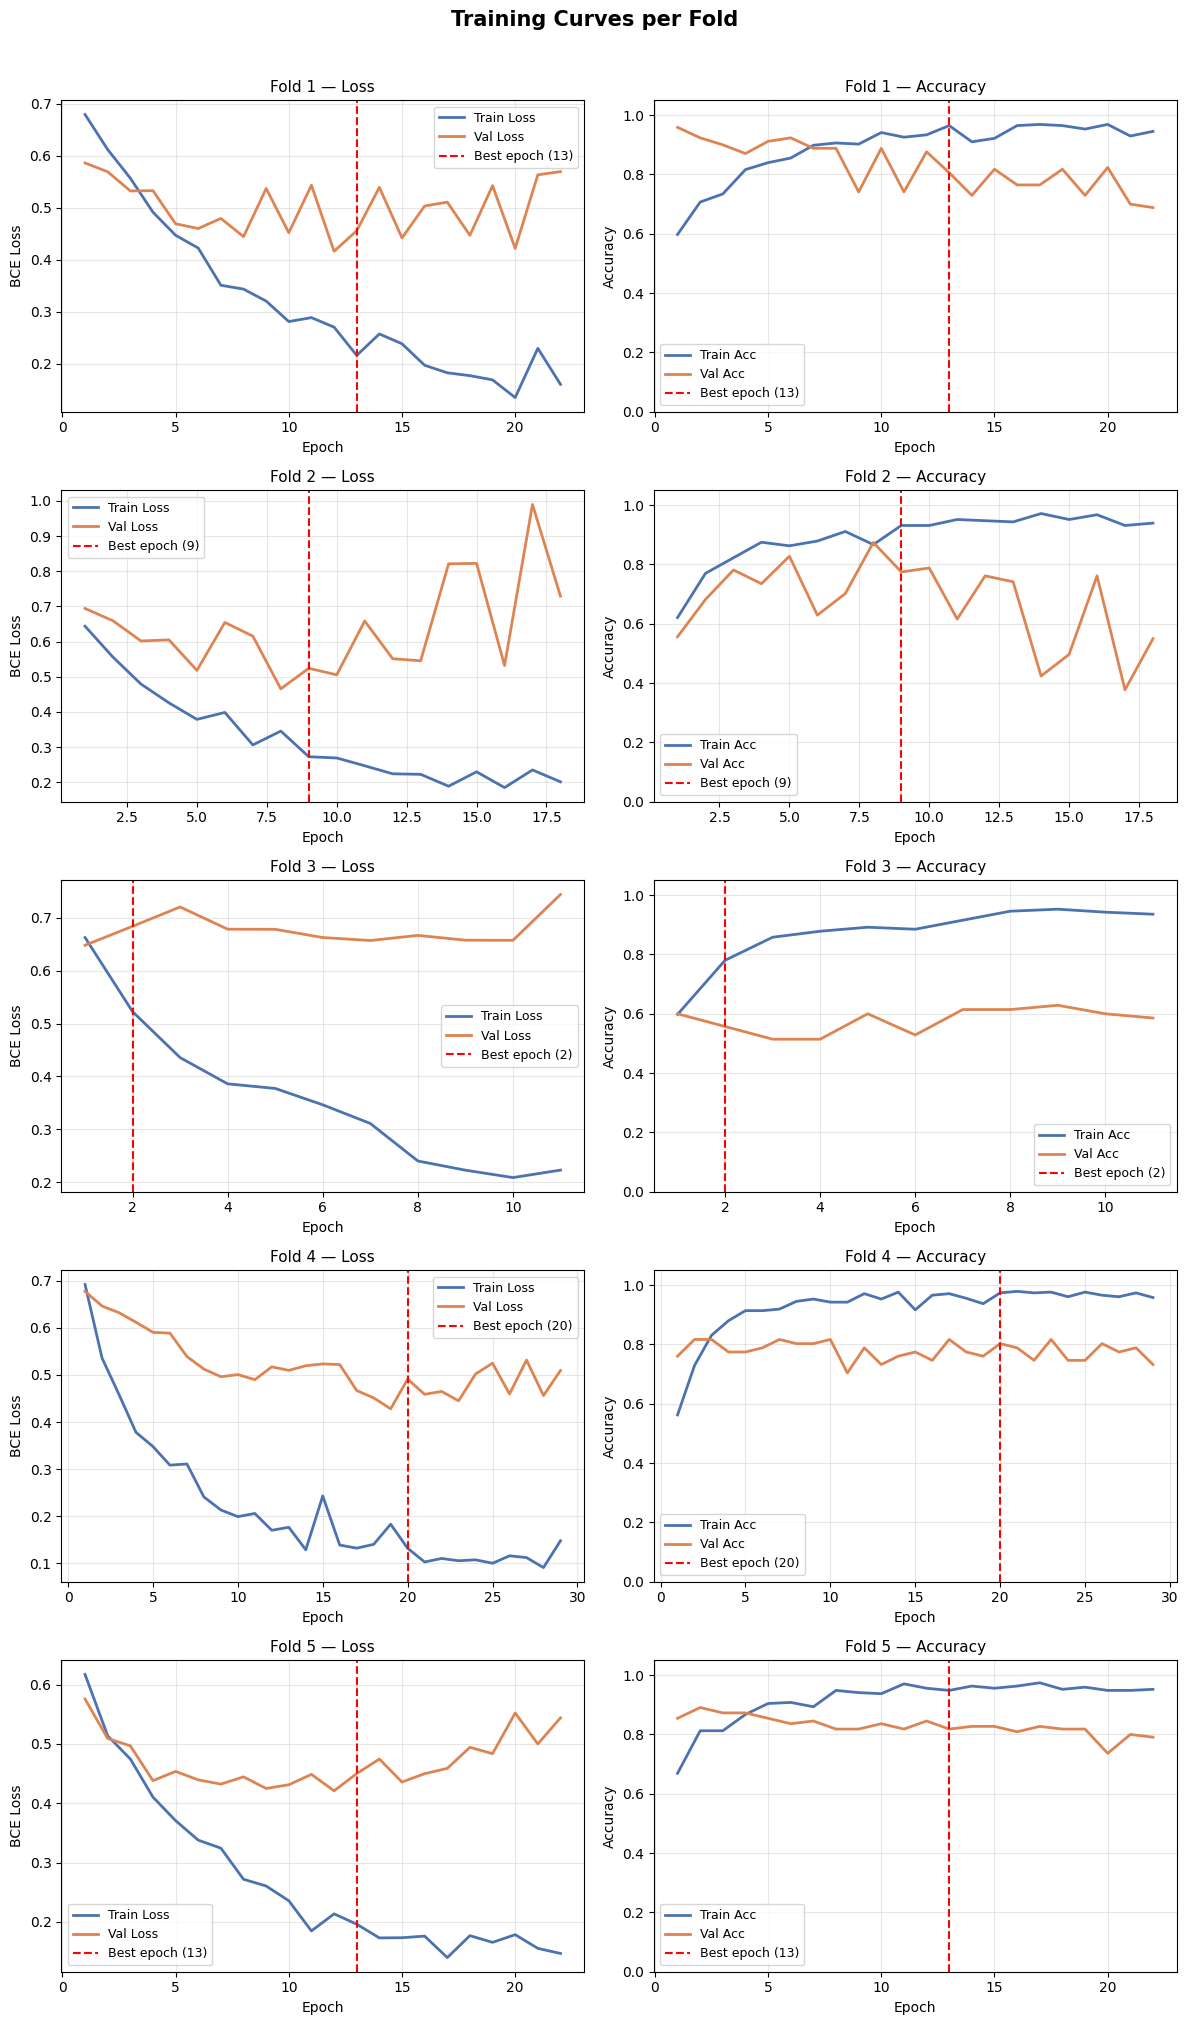

In [18]:
fig, axes = plt.subplots(
    nrows = n_folds,
    ncols = 2,
    figsize = (12, 4 * n_folds),
)

fig.suptitle("Training Curves per Fold", fontsize=15, fontweight="bold", y=1.01)

for i, result in enumerate(all_fold_results):
    history = result["history"]
    best_epoch = result["best_epoch"]
    fold_num = result["fold"]

    epochs = range(1, len(history["train_loss"]) + 1)

    # ==== Loss Curves ====
    ax_loss = axes[i, 0]
    ax_loss.plot(epochs, history["train_loss"], label="Train Loss",
                 color="#4C72B0", lw=2)
    ax_loss.plot(epochs, history["val_loss"],   label="Val Loss",
                 color="#DD8452", lw=2)
    ax_loss.axvline(best_epoch + 1, color="red", linestyle="--", lw=1.5,
                    label=f"Best epoch ({best_epoch + 1})")
    ax_loss.set_title(f"Fold {fold_num} — Loss", fontsize=11)
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("BCE Loss")
    ax_loss.legend(fontsize=9)
    ax_loss.grid(True, alpha=0.3)

    # ==== Accuracy Curves ====
    ax_acc = axes[i, 1]
    ax_acc.plot(epochs, history["train_acc"], label="Train Acc",
                color="#4C72B0", lw=2)
    ax_acc.plot(epochs, history["val_acc"],   label="Val Acc",
                color="#DD8452", lw=2)
    ax_acc.axvline(best_epoch + 1, color="red", linestyle="--", lw=1.5,
                   label=f"Best epoch ({best_epoch + 1})")
    ax_acc.set_title(f"Fold {fold_num} — Accuracy", fontsize=11)
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_ylim([0, 1.05])
    ax_acc.legend(fontsize=9)
    ax_acc.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Evaluation Model**

### Evaluation with Classification Report per Fold

In [19]:
fold_probs = []   # sigmoid probabilities (N_test,) per fold
fold_y_tests = []

for result in all_fold_results:
    model = result["model"]
    _, _, _, _, X_test, y_test = fold_data[fold_idx]
    X_test_t = torch.FloatTensor(X_test).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(X_test_t).squeeze().cpu().numpy()
    probs = 1 / (1 + np.exp(-logits))   # sigmoid
    fold_probs.append(probs)
    fold_y_tests.append(np.asarray(y_test).astype(int))

fold_probs     = np.array(fold_probs)        # (n_folds, N_test)
ensemble_probs = fold_probs.mean(axis=0)     # (N_test,)
print(f"✅ Predictions from {len(fold_probs)} folds  "
      f"({sum(len(y) for y in fold_y_tests)} total test samples)")

✅ Predictions from 5 folds  (620 total test samples)


In [23]:
# ── Per-fold metrics summary ───────────────────────────────────────────────────
print("\n" + "="*80)
print("SUMMARY OF ALL FOLDS (Per-Fold Test Performance)")
print("="*80 + "\n")

fold_summary = []

for i, (probs, y_true, result) in enumerate(
        zip(fold_probs, fold_y_tests, all_fold_results), start=1):
    fpr, tpr, thresholds = roc_curve(y_true, probs)
    j_idx  = np.argmax(tpr - fpr)
    thresh = float(thresholds[j_idx])

    preds          = (probs >= thresh).astype(int)
    cm             = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    auroc = roc_auc_score(y_true, probs)
    auprc = average_precision_score(y_true, probs)
    acc   = accuracy_score(y_true, preds)
    f1    = f1_score(y_true, preds, zero_division=0) 

    fold_summary.append({
        "Fold": i, "AUROC": f"{auroc:.4f}", "AUPRC": f"{auprc:.4f}",
        "Sensitivity": f"{sens:.3f}", "Specificity": f"{spec:.3f}",
        "Threshold": f"{thresh:.4f}", "Best Epoch": result["best_epoch"] + 1,
        "_auroc": auroc, "_auprc": auprc, "_sens": sens, "_spec": spec,"_acc"   : acc, "_f1"    : f1,
    })

cols = ["Fold", "AUROC", "AUPRC", "Sensitivity", "Specificity", "Threshold", "Best Epoch"]
print(pd.DataFrame(fold_summary)[cols].to_string(index=False))

aurocs = [r["_auroc"] for r in fold_summary]
auprcs = [r["_auprc"] for r in fold_summary]
accs   = [r["_acc"]   for r in fold_summary]
f1s    = [r["_f1"]    for r in fold_summary]
senss  = [r["_sens"]  for r in fold_summary]
specs  = [r["_spec"]  for r in fold_summary]


print(f"\n{'-'*80}")
print(f"Mean AUROC       : {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")
print(f"Mean AUPRC       : {np.mean(auprcs):.4f} ± {np.std(auprcs):.4f}")
print(f"Mean Accuracy    : {np.mean(accs):.3f}  ± {np.std(accs):.3f}")
print(f"Mean F1          : {np.mean(f1s):.3f}   ± {np.std(f1s):.3f}")
print(f"Mean Sensitivity : {np.mean(senss):.3f} ± {np.std(senss):.3f}")
print(f"Mean Specificity : {np.mean(specs):.3f} ± {np.std(specs):.3f}")
print(f"{'-'*80}")


SUMMARY OF ALL FOLDS (Per-Fold Test Performance)

 Fold  AUROC  AUPRC Sensitivity Specificity Threshold  Best Epoch
    1 0.9812 0.9906       0.964       0.902    0.5546          13
    2 0.9891 0.9949       0.904       1.000    0.6658           9
    3 0.9495 0.9698       0.976       0.854    0.4293           2
    4 1.0000 1.0000       1.000       1.000    0.4825          20
    5 0.7993 0.8979       0.771       0.732    0.1833          13

--------------------------------------------------------------------------------
Mean AUROC       : 0.9438 ± 0.0742
Mean AUPRC       : 0.9706 ± 0.0378
Mean Accuracy    : 0.915  ± 0.082
Mean F1          : 0.934   ± 0.065
Mean Sensitivity : 0.923 ± 0.082
Mean Specificity : 0.898 ± 0.100
--------------------------------------------------------------------------------


### Visualization of Evaluation with AUROC Curves and Confusion Matrix per Fold

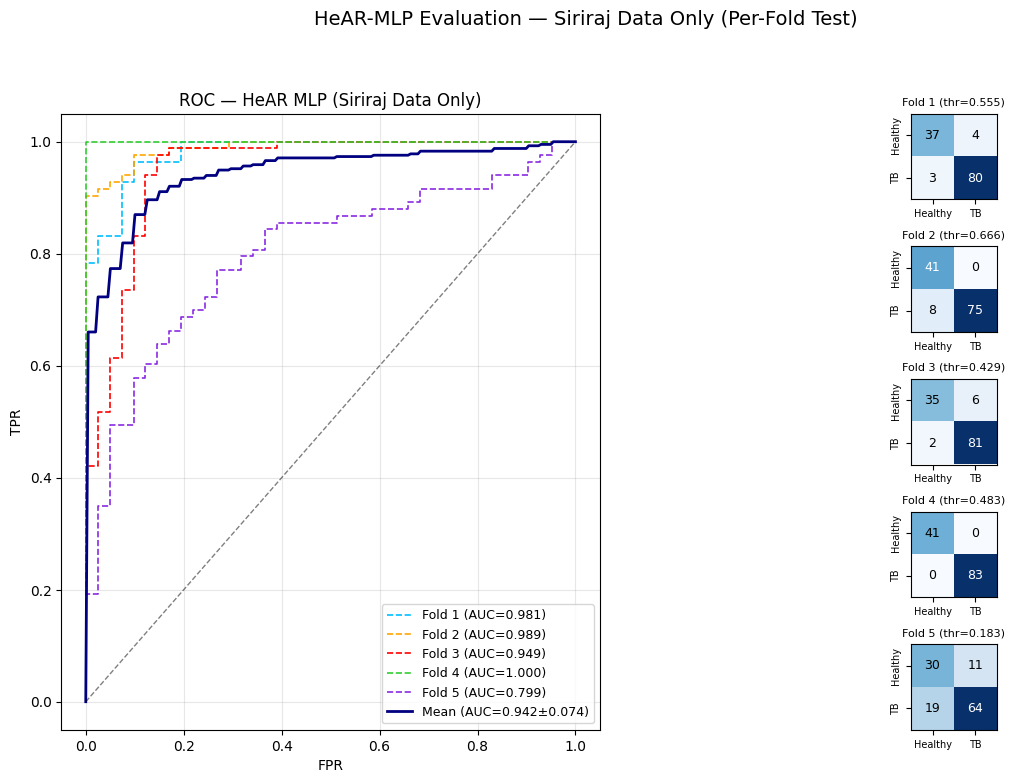

In [24]:
# ── ROC curves + confusion matrices ────────────────────────────────────────────
FOLD_COLORS = ["#00BFFF", "#FFA500", "#FF0000", "#32CD32", "#8A2BE2"]
mean_fpr = np.linspace(0, 1, 200)
fold_fprs, fold_tprs, fold_aucs = [], [], []

for y_true, probs in zip(fold_y_tests, fold_probs):
    fpr, tpr, _ = roc_curve(y_true, probs)
    fold_fprs.append(fpr); fold_tprs.append(tpr); fold_aucs.append(auc(fpr, tpr))

interp_tprs = [np.interp(mean_fpr, f, t) for f, t in zip(fold_fprs, fold_tprs)]
mean_tpr    = np.mean(interp_tprs, axis=0); mean_tpr[0] = 0.0
mean_auc    = auc(mean_fpr, mean_tpr); std_auc = np.std(fold_aucs)

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.4, 1], wspace=0.35)

# LEFT: ROC
ax_roc = fig.add_subplot(gs[0])
for i, (fpr, tpr, a) in enumerate(zip(fold_fprs, fold_tprs, fold_aucs)):
    ax_roc.plot(fpr, tpr, color=FOLD_COLORS[i], lw=1.2, ls="--",
                label=f"Fold {i+1} (AUC={a:.3f})")
ax_roc.plot(mean_fpr, mean_tpr, color="navy", lw=2,
            label=f"Mean (AUC={mean_auc:.3f}±{std_auc:.3f})")
ax_roc.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("ROC — HeAR MLP (Siriraj Data Only)"); ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)

# RIGHT: Confusion matrices
gs_cm = gridspec.GridSpecFromSubplotSpec(n_folds, 1, subplot_spec=gs[1], hspace=0.55)
for i, (y_true, probs) in enumerate(zip(fold_y_tests, fold_probs)):
    fpr, tpr, ths = roc_curve(y_true, probs)
    thresh = float(ths[np.argmax(tpr - fpr)])
    preds = (probs >= thresh).astype(int)
    cm = confusion_matrix(y_true, preds)
    ax = fig.add_subplot(gs_cm[i])
    ax.imshow(cm, cmap=plt.cm.Blues, vmin=0)
    ax.set_title(f"Fold {i+1} (thr={thresh:.3f})", fontsize=8)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Healthy","TB"], fontsize=7)
    ax.set_yticks([0,1]); ax.set_yticklabels(["Healthy","TB"], fontsize=7, rotation=90, va="center")
    mid = cm.max() / 2
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center", fontsize=9,
                    color="white" if cm[r, c] > mid else "black")

plt.suptitle("HeAR-MLP Evaluation — Siriraj Data Only (Per-Fold Test)", fontsize=14, y=1.01)
plt.show()

In [ ]:
# ── False Negative (FN) Error Analysis ─────────────────────────────────────────
print("\n" + "="*80)
print("FALSE NEGATIVE (FN) ERROR ANALYSIS — Missed TB Segments")
print("="*80)

for i, result in enumerate(all_fold_results):
    fold_num = result["fold"]
    model    = result["model"]

    # Reconstruct test set — metadata + aligned embeddings
    test_subjs = splits_info["folds"][i]["test_subj"]
    test_mask  = df["subject_id"].isin(test_subjs)
    df_test    = df[test_mask].reset_index(drop=True)
    X_test_np  = embeddings[test_mask.values].astype(np.float32)
    y_true     = df_test["label"].values.astype(int)

    # Get model probabilities
    X_test_t = torch.FloatTensor(X_test_np).to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(X_test_t).squeeze().cpu().numpy().reshape(-1)
    probs = 1 / (1 + np.exp(-logits))

    # Youden's J optimal threshold
    fpr_f, tpr_f, thresholds_f = roc_curve(y_true, probs)
    thresh = float(thresholds_f[np.argmax(tpr_f - fpr_f)])
    preds  = (probs >= thresh).astype(int)

    fn_mask = (y_true == 1) & (preds == 0)
    fn_df   = df_test[fn_mask][["subject_id", "file_name", "category", "label"]].copy()
    fn_df["prob"] = np.round(probs[fn_mask], 4)
    fn_df["pred"] = 0

    total_tb = (y_true == 1).sum()
    print(f"\n--- Fold {fold_num} | Threshold: {thresh:.4f} | FN: {fn_mask.sum()} / {total_tb} TB segments ---")
    if fn_mask.sum() > 0:
        print(fn_df.to_string(index=False))
    else:
        print("  ✅ No false negatives in this fold.")

print(f"\n{'='*80}")
